In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Challenges

## Optique

### Lentilles

#### Viseur

In [5]:
def O2A2(O1A):
    O2O1 = -16
    fp1 = 5
    fp2 = 1
    O1A1 = 1/(1/fp1+1/O1A)
    O2A1 = O2O1 + O1A1
    return 1/(1/fp2+1/O2A1)

def O1A(O2A2):
    O1O2 = 16.4
    fp1 = 5.4
    fp2 = 1.5
    O2A1 = 1/(1/O2A2-1/fp2)
    O1A1 = O1O2 + O2A1
    return 1/(1/O1A1-1/fp1)

def o1a(O2A2):
    fp1 = 5.4
    fp2 = 1.5
    d = 16.4
    return fp1*(d*fp2-d*O2A2+fp2*O2A2)/((fp1-d)*(fp2-O2A2)-fp2*O2A2)

PP = -25
PR = -1e15
print(O1A(PP)-O1A(PR))

0.02719021964359669


### Électricité

#### Diode zener

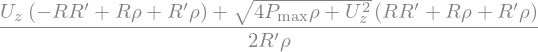

5.70735201617853


In [21]:
from sympy import *
from IPython.display import display
init_printing(use_latex=True)
R, Rp, rho, i, E, Uz, iz = symbols("R R' \\rho, i, E, U_z, i_z")
system = [E-R*i-rho*iz-Uz, E-R*i-Rp*(i-iz)]
sol = linsolve(system, iz, i)
iz = sol.args[0][0]
Vz = Uz + rho*iz
P = iz*Vz
Pmax = symbols('P_\\text{max}')
Emax = solve(P-Pmax, E)[1]
display(Emax)
print(Emax.subs({R:44, Rp:271, rho:4.4, Uz:4.6, Pmax:34e-3}))

## Chimie

### Cinétique 

#### Pyrolyse de l'éthanal

k = 0.05599984875570869


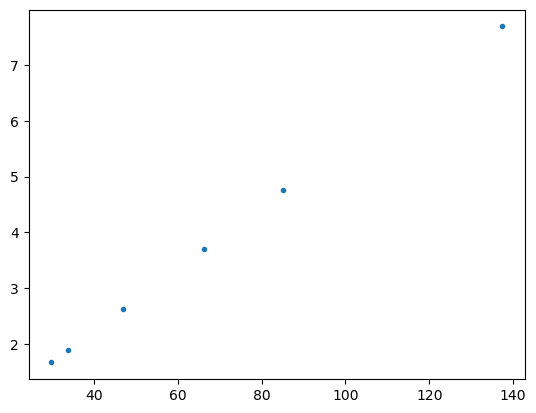

In [38]:
c = np.array([0.13, 0.21, 0.27, 0.38, 0.53, 0.60])
t12 = np.array([137.363, 85.034, 66.138, 46.992, 33.693, 29.762])
plt.plot(t12, 1/c, '.')
a,b = np.polyfit(1/c, t12, 1)
print(f"k = {1/a}")

#### Scintigraphie de la thyroide

In [39]:
t12 = 13.2*60
dt = 130
lam = np.log(2)/t12
repOK = 100*np.exp(-lam*dt)
print(repOK)

89.24594875805153


#### Thermolyse de l’oxyde de méthyle

In [40]:
P0 = 0.460
P1 = 0.467
t = 20
k = -1/t*np.log((3-P1/P0)/2)
print(k)

0.0003818894724058769


### Acide-Base

#### Définition du pH

In [41]:
c=  5.85e-5
print(np.log10(c))

-4.23284413391782


### Oxydoréduction

#### Détermination d'une constante d'équilibre

In [42]:
c1 = 7e-3
c2 = 7e-2
U = 1.14
T = 294
R = 8.314
F = 96485
print(np.log10(c1*np.exp(F*U/R/T)/(c2*(c2-2*c1)**2)))
#xiv = c1 - c2*np.exp(-F*U/R/T)
#K = xiv/(c1-xiv)/(c2-xiv)**2

21.04664110029015


#### Réaction prépondérante

In [104]:
Ka2 = 10**(-3.8)
Ka1 = 10**(-3.2)
V = 250e-3
n2 = 8e-2
n1 = 5e-2
xi = np.sqrt(V*Ka2*n2)
print((n2-xi)/V)
def f(x):
    res = [0,0]
    res[0] = (x[0]+x[1])*x[0]/(n2-x[0])/V-Ka2
    res[1] = (x[0]+x[1])*x[1]/(n1-x[1])/V-Ka1
    return res
xi1 = fsolve(f,[7e-3, 7e-3])[0]
print((n2-xi1)/V)

0.31287844243449825
0.3161623116172674


Dosage d'une solution d'ammoniac (conductimétrie)

In [113]:
lNH4 = 7.34
lCl = 7.63
Ca = 0.17e3 # mol/m³
Vb = 14e-6 # m³
p = (lNH4 + lCl)*Ca/Vb
print(p/1e3)


181778.5714285714


## Thermodynamique

### Premier principe

#### Chauffage électrique

In [43]:
T = 300
V = 2e-3
p = 1e5
g = 1.4
R = 8.314
n = p*V/R/T
VB = V*2**(-1/g)
VA = 2*V - VB
TA = 2*p*VA/n/R
TB = 2*p*VB/n/R
Q = 2*p*V/(g-1)
dU1 = n*R/(g-1)*(TA-T)
dU2 = n*R/(g-1)*(TB-T)
dU = dU1 + dU2
print(f"VA = {VA*1e3:.2f} L")
print(f"TA = {TA:.2f} K")
print(f"VB = {VB*1e3:.2f} L")
print(f"TB = {TB:.2f} K")
print(f"Q = {Q:.2f} J")
print(f"dU1 + dU2 = {dU1:.2f} + {dU2:.2f} = {dU:.2f} J")

VA = 2.78 L
TA = 834.30 K
VB = 1.22 L
TB = 365.70 K
Q = 1000.00 J
dU1 + dU2 = 890.49 + 109.51 = 1000.00 J


### Machines thermiques

#### Cycle Diesel

In [44]:
T1 = 295
T2 = 1034
V1 = 3e-3
V3 = 0.28e-3
g = 1.4
R = 8.314
P1 = 1e5
n = P1*V1/R/T1
V2 = V1*(T1/T2)**(1/(g-1))
T3 = T2*V3/V2
T4 = T3*(V3/V1)**(g-1)
P2 = P1*(V1/V2)**g
Cp = n*R*g/(g-1)
Cv = n*R/(g-1)
W12 = Cv*(T2-T1)
W23 = P2*(V2-V3)
W34 = Cv*(T4-T3)
W = W12 + W23 + W34
Q23 = Cp*(T3-T2)
eta = -W/Q23
print(f"η = {eta:.4f}")
print(f"T3 = {T3:.2f}")
print(f"T4 = {T4:.2f}")
print(f"W23 = {W23:.2f}")
print(f"V2 = {V2:.2e}")
print(f"P2 = {P2:.2e}")
print(f"W = {W:.2e}")
print(f"W' = {n*R/(g-1)*(T1-T4) + g*n*R/(g-1)*(T3-T2):.2e}")
print(f"Carnot : η = {1-T1/T3}")

η = 0.6599
T3 = 2219.75
T4 = 859.64
W23 = -1205.85
V2 = 1.30e-04
P2 = 8.06e+06
W = -2.78e+03
W' = 2.78e+03
Carnot : η = 0.8671020157861309


In [45]:
0.25/0.12*1020

2125.0

In [46]:
n*R/(g-1)*(T1-T4)

-1435.5340667544795

## Electromagnétisme

### Forces de laplace

#### Rails de laplace en RSF

9.196738552334736 6.138489735241171


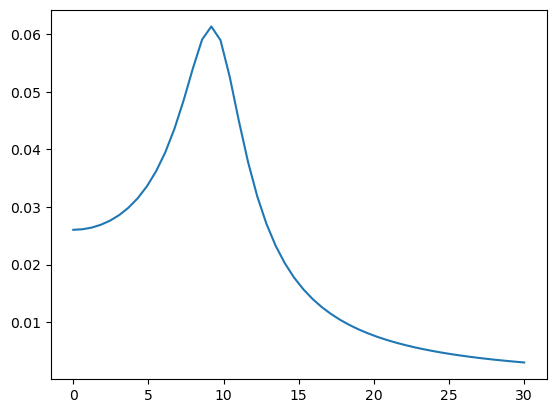

In [60]:
B = 1.1
a = 6.7e-2
M = 50e-3
k = 4.67
I = 1.65
l = 0.21

w0 = np.sqrt(k/M)
Q = np.sqrt(k*M/l**2)
wmax = w0*np.sqrt(1-1/2/Q**2)

def f(w):
    return I*a*B/np.sqrt((k-M*w**2)**2 + l**2*w**2)

print(wmax, f(wmax)*100)
w = np.linspace(0, 30)
plt.plot(w, f(w))

### Induction

#### Freinage par induction 2

In [72]:
m = 27e-3
I = 1242
h = 20e-2
a = 5.1e-2
R = 2.1
N = 100
L = 5.6e-2
v0 = 14
mu0 = 4*np.pi*1e-7
F = (mu0*N*I*h*a)**2*v0/(2*np.pi*L*(L+a))**2/R
a = F/m
print(f"Accélération = {a:.4e}")

alpha = (mu0*I*h*a)**2/(m*4*np.pi**2*R)
vlim = alpha/3/L**3
print(f"vitesse limite = {vlim:.2e} m/s")

Accélération = 4.4147e-01
vitesse limite = 1.61e-05 m/s


####  Freinage par induction 1

In [75]:
m = 25e-3
l = 14e-2
R = 2
g = 9.81
Blim = np.sqrt(8*R*m/3/l**2*np.sqrt(3*g/2/l))
print(f"Blim = {Blim:.4e} T")

Blim = 8.3512e+00 T


#### Chauffage par induction

In [86]:
a = 3.1e-2
I0 = 18
f = 26e3
w = 2*np.pi*f
n = 160
mu0 = 4*np.pi*1e-7
B = mu0*n*I0
phi = B*np.pi*a**2
R = 0.22
e = dphidt = w*phi
Pamp = e**2/R
Pmoy = Pamp/2 
print(f"Puissance moyenne = {Pmoy:.4e} W")

Puissance moyenne = 7.2411e+00 W


1.78496139832467